# Clustering and association rule mining

This notebook studies two questions for a drone delivery company:

1. Where should drone depots be placed so that they are close to customers?
2. Which product groups are useful cross-selling triggers?

The work follows the CRISP-DM stages: business understanding, data understanding, data preparation, modelling, evaluation, and deployment recommendations.

## 1. Business understanding

For the depot problem, a good solution should keep customers close to their assigned depot. The customer coordinates have no units, road network, terrain, or flight restrictions, so I use straight-line distance as a planning approximation. The final site choice would still need a feasibility check.

For product recommendations, the aim is to find groups that occur together more often than chance. I focus on rules with enough support to matter commercially and enough lift to add information beyond simply recommending popular groups.

## 2. Setup and data loading

The first cell imports the tools used later. `find_data_file` checks a few relative paths, which lets the notebook run from the repository root, the `dkko` folder, or the assignments folder. A fixed random seed makes the k-means result repeatable.

In [1]:
import os
import tempfile
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "mplconfig_assignment"))

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


def find_data_file(filename):
    candidates = [
        Path("dkko/datasets/drone_delivery") / filename,
        Path("datasets/drone_delivery") / filename,
        Path("../datasets/drone_delivery") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")


location_path = find_data_file("drone_cust_locations.csv")
product_path = find_data_file("drone_prod_groups.csv")
print("Locations:", location_path)
print("Products: ", product_path)

Locations: datasets\drone_delivery\drone_cust_locations.csv
Products:  datasets\drone_delivery\drone_prod_groups.csv


The location file uses semicolons, while the product file uses commas and contains spaces after some commas. Supplying the correct separators here prevents all location values from being read as one text column and cleans the product headers at the same time.

In [2]:
locations = pd.read_csv(location_path, sep=";")
products = pd.read_csv(product_path, skipinitialspace=True)
products.columns = products.columns.str.strip()

print(f"Customer rows: {len(locations):,}")
print(f"Transaction rows: {len(products):,}")
display(locations.head())
display(products.head())

Customer rows: 5,956
Transaction rows: 100,000


,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


## 3. Part 1 — depot locations

### 3.1 Data understanding and preparation

Before clustering, I check missing values, duplicate IDs, and the coordinate ranges. Only `x` and `y` go into the models; `clientid` is an identifier, not a measure of location.

In [3]:
location_quality = pd.Series({
    "missing values": int(locations.isna().sum().sum()),
    "duplicate client IDs": int(locations["clientid"].duplicated().sum()),
    "number of clients": len(locations),
})

display(location_quality.to_frame("value"))
display(locations[["x", "y"]].describe().round(2))

X = locations[["x", "y"]].to_numpy()

,value
missing values,0
duplicate client IDs,0
number of clients,5956


,x,y
count,5956.00,5956.00
mean,508.82,427.55
std,271.06,289.04
min,0.02,0.04
25%,282.58,170.08
50%,518.10,397.79
75%,727.16,669.98
max,999.53,999.73


The coordinates are already on the same scale, so standardising them would not help here. The scatterplot below shows the spatial shape before the clustering labels influence our interpretation.

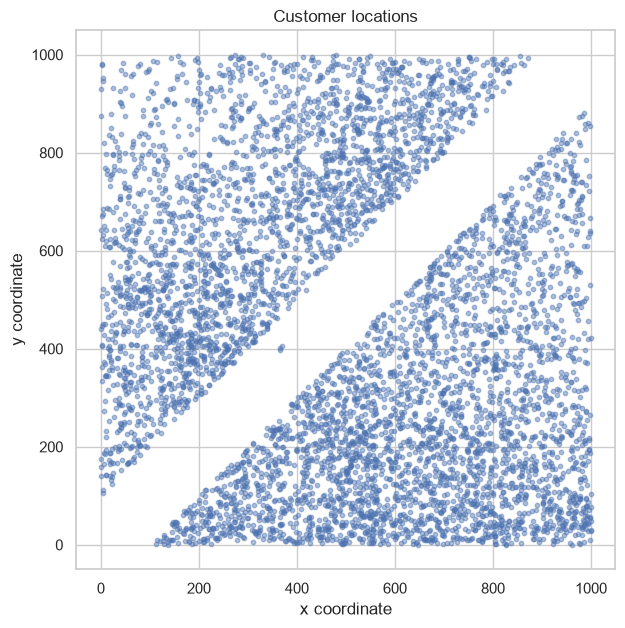

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(locations["x"], locations["y"], s=10, alpha=0.45)
ax.set(title="Customer locations", xlabel="x coordinate", ylabel="y coordinate")
ax.set_aspect("equal", adjustable="box")
plt.show()

There are two broad land-like areas separated by an empty diagonal band. This could represent water, an unpopulated area, or simply the boundary between service regions. The points are spread across the shapes rather than forming three obvious round towns. That matters because k-means will still divide the map even when the visual clusters are not sharply separated. It may also assign a customer across the empty band if that depot is closest by straight-line distance.

### 3.2 K-means with three depots

`N_DEPOTS` is the only value that needs to change for a different number of depots. K-means assigns every client to the nearest centroid and then updates the centroids until the assignments settle. In this setting, the final centroids are the proposed depot coordinates.

In [5]:
N_DEPOTS = 3

kmeans = KMeans(
    n_clusters=N_DEPOTS,
    n_init=20,
    random_state=RANDOM_STATE,
)
raw_labels = kmeans.fit_predict(X)

# Number depots from west to east so the IDs are easier to read on the map.
west_to_east = np.argsort(kmeans.cluster_centers_[:, 0])
label_map = {old_label: new_id for new_id, old_label in enumerate(west_to_east, start=1)}

locations_km = locations.copy()
locations_km["depot_id"] = pd.Series(raw_labels).map(label_map).to_numpy()

depot_locations_3 = pd.DataFrame(
    kmeans.cluster_centers_[west_to_east], columns=["x", "y"]
)
depot_locations_3.insert(0, "depot_id", range(1, N_DEPOTS + 1))
depot_locations_3[["x", "y"]] = depot_locations_3[["x", "y"]].round(2)

The added `depot_id` is the closest centroid for each client. I print the requested first ten rows and the three proposed depot coordinates separately.

In [6]:
display(locations_km.head(10))
display(depot_locations_3)

,clientid,x,y,depot_id
0,1,622.771572,164.857623,3
1,2,416.357298,630.193634,2
2,3,292.735020,567.333231,1
3,4,737.211288,166.225676,3
4,5,540.475375,682.912298,2
5,6,535.469492,318.439661,3
6,7,640.380050,870.833221,2
7,8,235.772075,359.048203,1
8,9,481.896884,661.491838,2
9,10,730.032789,312.177817,3


,depot_id,x,y
0,1,194.41,393.31
1,2,554.22,787.79
2,3,697.40,210.10


The colours show each depot's service area. The black X markers are the centroids, not existing customer locations, so they should be treated as target areas for a later site search.

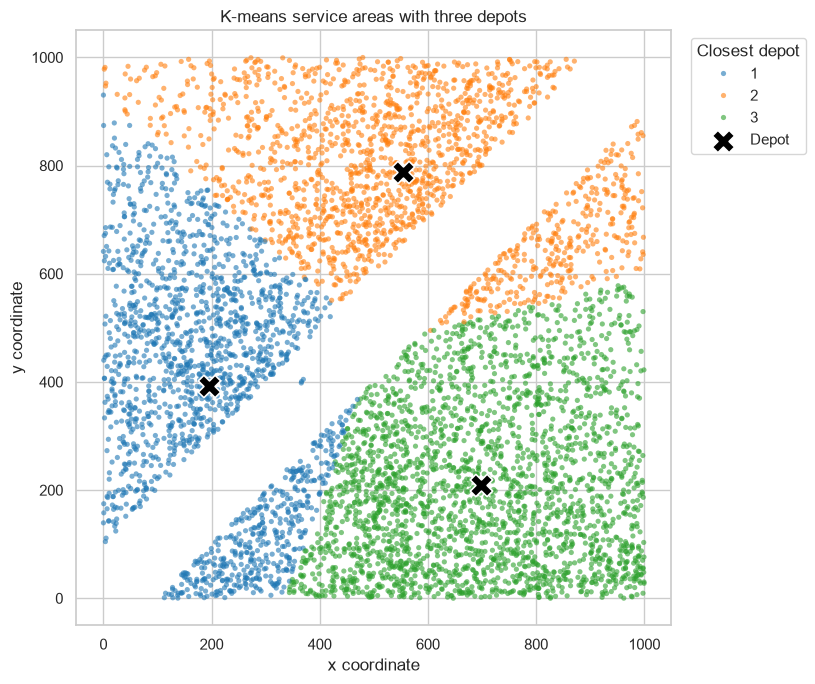

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=locations_km,
    x="x",
    y="y",
    hue="depot_id",
    palette="tab10",
    s=14,
    alpha=0.60,
    linewidth=0,
    ax=ax,
)
ax.scatter(
    depot_locations_3["x"],
    depot_locations_3["y"],
    marker="X",
    s=260,
    c="black",
    edgecolors="white",
    linewidths=1.2,
    label="Depot",
)
ax.set(title="K-means service areas with three depots", xlabel="x coordinate", ylabel="y coordinate")
ax.set_aspect("equal", adjustable="box")
ax.legend(title="Closest depot", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3.3 Choosing the number of depots

There is no single statistical answer because an extra depot also has a financial cost. I compare 2–15 depots using:

- **inertia:** total squared distance to the assigned depot (lower is better);
- **silhouette score:** how clearly the service areas are separated (higher is better);
- **fit time:** the model fitting time on this computer.

The silhouette calculation uses a reproducible sample of 3,000 clients to keep this comparison quick. It is an evaluation sample only; every k-means model is fitted on all customers.

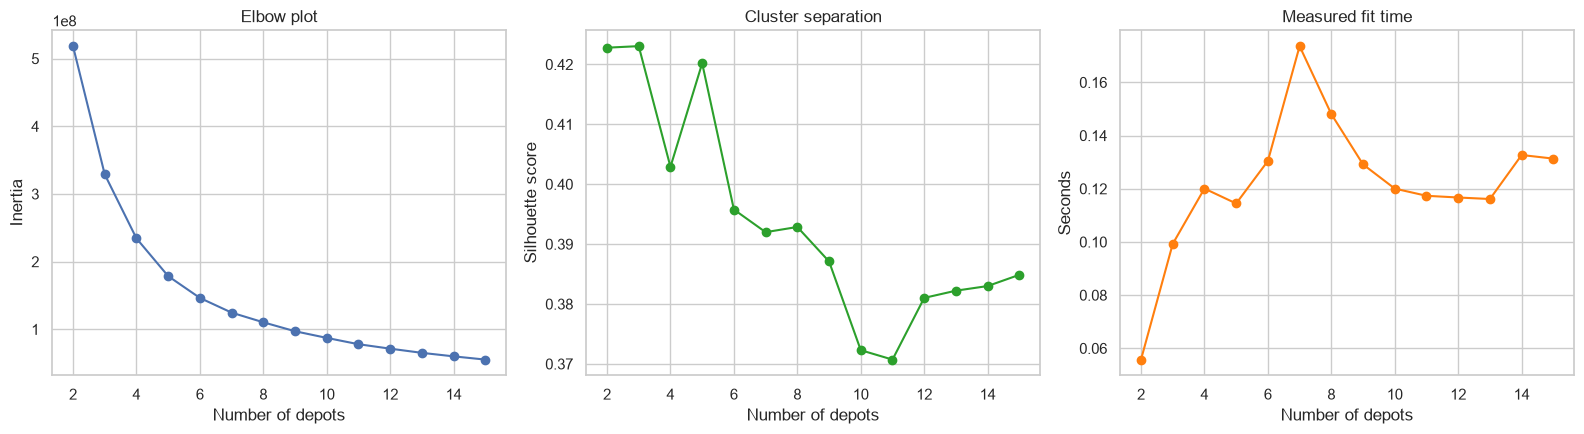

,depots,inertia,silhouette,fit_seconds
0,2,518412001.0,0.423,0.0558
1,3,328921535.0,0.423,0.0993
2,4,234346419.0,0.403,0.1201
3,5,178581942.0,0.420,0.1144
4,6,146336349.0,0.396,0.1304
5,7,124621848.0,0.392,0.1736
6,8,110329530.0,0.393,0.1480
7,9,97097807.0,0.387,0.1291
8,10,87283803.0,0.372,0.1200
9,11,77952344.0,0.371,0.1173


In [8]:
k_results = []
kmeans_models = {}

for k in range(2, 16):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    start = perf_counter()
    model.fit(X)
    fit_seconds = perf_counter() - start
    kmeans_models[k] = model

    score = silhouette_score(
        X,
        model.labels_,
        sample_size=3000,
        random_state=RANDOM_STATE,
    )
    k_results.append({
        "depots": k,
        "inertia": model.inertia_,
        "silhouette": score,
        "fit_seconds": fit_seconds,
    })

k_scores = pd.DataFrame(k_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(k_scores["depots"], k_scores["inertia"], "o-")
axes[0].set(title="Elbow plot", xlabel="Number of depots", ylabel="Inertia")

axes[1].plot(k_scores["depots"], k_scores["silhouette"], "o-", color="tab:green")
axes[1].set(title="Cluster separation", xlabel="Number of depots", ylabel="Silhouette score")

axes[2].plot(k_scores["depots"], k_scores["fit_seconds"], "o-", color="tab:orange")
axes[2].set(title="Measured fit time", xlabel="Number of depots", ylabel="Seconds")

plt.tight_layout()
plt.show()

display(k_scores.round({"inertia": 0, "silhouette": 3, "fit_seconds": 4}))

The inertia curve falls quickly at first and then flattens gradually; there is no perfectly sharp elbow. The highest silhouette values are around two to five depots, while larger values deliberately split continuous areas into smaller delivery zones. Increasing from 3 to 10 depots raises the fit time only slightly on this dataset, and both finish in well under a second on a typical laptop. Runtime is not the deciding issue here; depot cost versus delivery distance is.

The next table gives the coordinates for 3, 5, and 10 depots. It also reports the mean and 90th-percentile straight-line customer distance, which are easier to connect to operations than inertia.

In [9]:
option_rows = []
center_rows = []

for k in [3, 5, 10]:
    model = kmeans_models.get(k)
    if model is None:
        model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X)
        kmeans_models[k] = model

    distances = np.linalg.norm(X - model.cluster_centers_[model.labels_], axis=1)
    option_rows.append({
        "depots": k,
        "mean_distance": distances.mean(),
        "p90_distance": np.percentile(distances, 90),
        "maximum_distance": distances.max(),
        "silhouette": silhouette_score(
            X, model.labels_, sample_size=3000, random_state=RANDOM_STATE
        ),
    })

    order = np.argsort(model.cluster_centers_[:, 0])
    for depot_id, old_label in enumerate(order, start=1):
        center_rows.append({
            "number_of_depots": k,
            "depot_id_west_to_east": depot_id,
            "x": model.cluster_centers_[old_label, 0],
            "y": model.cluster_centers_[old_label, 1],
        })

depot_options = pd.DataFrame(option_rows)
recommended_centres = pd.DataFrame(center_rows)

display(depot_options.round(2))
display(recommended_centres.round(2))

,depots,mean_distance,p90_distance,maximum_distance,silhouette
0,3,212.34,347.13,584.53,0.42
1,5,156.71,249.20,508.17,0.42
2,10,111.70,171.43,263.40,0.37


,number_of_depots,depot_id_west_to_east,x,y
0,3,1,194.41,393.31
1,3,2,554.22,787.79
2,3,3,697.40,210.10
3,5,1,162.30,498.91
4,5,2,437.32,147.94
5,5,3,490.55,826.18
6,5,4,804.88,151.26
7,5,5,806.33,530.32
8,10,1,107.65,329.97
9,10,2,186.94,835.91


Ten depots cut the mean straight-line distance from about 212 to 112 coordinate units, a reduction of roughly 47% compared with three depots. Five depots are a middle option at about 157 units. These gains should be converted to flight time, energy use, and service-level improvements, then compared with the fixed cost of each extra depot.

### 3.4 Agglomerative hierarchical clustering

Ward's agglomerative method starts with individual clients and repeatedly joins groups while trying to limit the increase in within-cluster variance. Unlike k-means, it does not directly optimise movable depot centroids. I therefore calculate the mean coordinate of each final group as its suggested depot position.

For a fair comparison, both methods use the same customer coordinates and the same values of k. The adjusted Rand index (ARI) measures how similar the two assignments are: 1 means identical partitions and values near 0 mean little agreement beyond chance.

In [10]:
hierarchical_models = {}
comparison_rows = []

for k in [3, 5, 10]:
    start = perf_counter()
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage="ward")
    h_labels = hierarchical.fit_predict(X)
    h_seconds = perf_counter() - start
    hierarchical_models[k] = hierarchical

    h_centres = np.vstack([X[h_labels == label].mean(axis=0) for label in range(k)])
    h_distances = np.linalg.norm(X - h_centres[h_labels], axis=1)

    km = kmeans_models[k]
    km_distances = np.linalg.norm(X - km.cluster_centers_[km.labels_], axis=1)

    comparison_rows.extend([
        {
            "method": "K-means",
            "depots": k,
            "fit_seconds": k_scores.loc[k_scores["depots"].eq(k), "fit_seconds"].iloc[0],
            "silhouette": silhouette_score(
                X, km.labels_, sample_size=3000, random_state=RANDOM_STATE
            ),
            "mean_distance": km_distances.mean(),
            "p90_distance": np.percentile(km_distances, 90),
            "ARI_vs_kmeans": 1.0,
        },
        {
            "method": "Hierarchical (Ward)",
            "depots": k,
            "fit_seconds": h_seconds,
            "silhouette": silhouette_score(
                X, h_labels, sample_size=3000, random_state=RANDOM_STATE
            ),
            "mean_distance": h_distances.mean(),
            "p90_distance": np.percentile(h_distances, 90),
            "ARI_vs_kmeans": adjusted_rand_score(km.labels_, h_labels),
        },
    ])

method_comparison = pd.DataFrame(comparison_rows)
display(method_comparison.round(3))

,method,depots,fit_seconds,silhouette,mean_distance,p90_distance,ARI_vs_kmeans
0,K-means,3,0.099,0.423,212.342,347.125,1.000
1,Hierarchical (Ward),3,0.418,0.402,221.261,354.991,0.449
2,K-means,5,0.114,0.420,156.709,249.195,1.000
3,Hierarchical (Ward),5,0.463,0.367,167.742,285.209,0.709
4,K-means,10,0.120,0.372,111.698,171.425,1.000
5,Hierarchical (Ward),10,0.456,0.346,119.233,188.422,0.585


The two methods do not make identical boundaries, especially with three depots. On this run, Ward clustering is computationally practical and its timing is similar to k-means. That should not be generalised to a much larger customer database: agglomerative clustering stores and processes many pairwise relationships, while k-means scales more comfortably.

The plots below make the different boundaries visible for 3 and 10 depots.

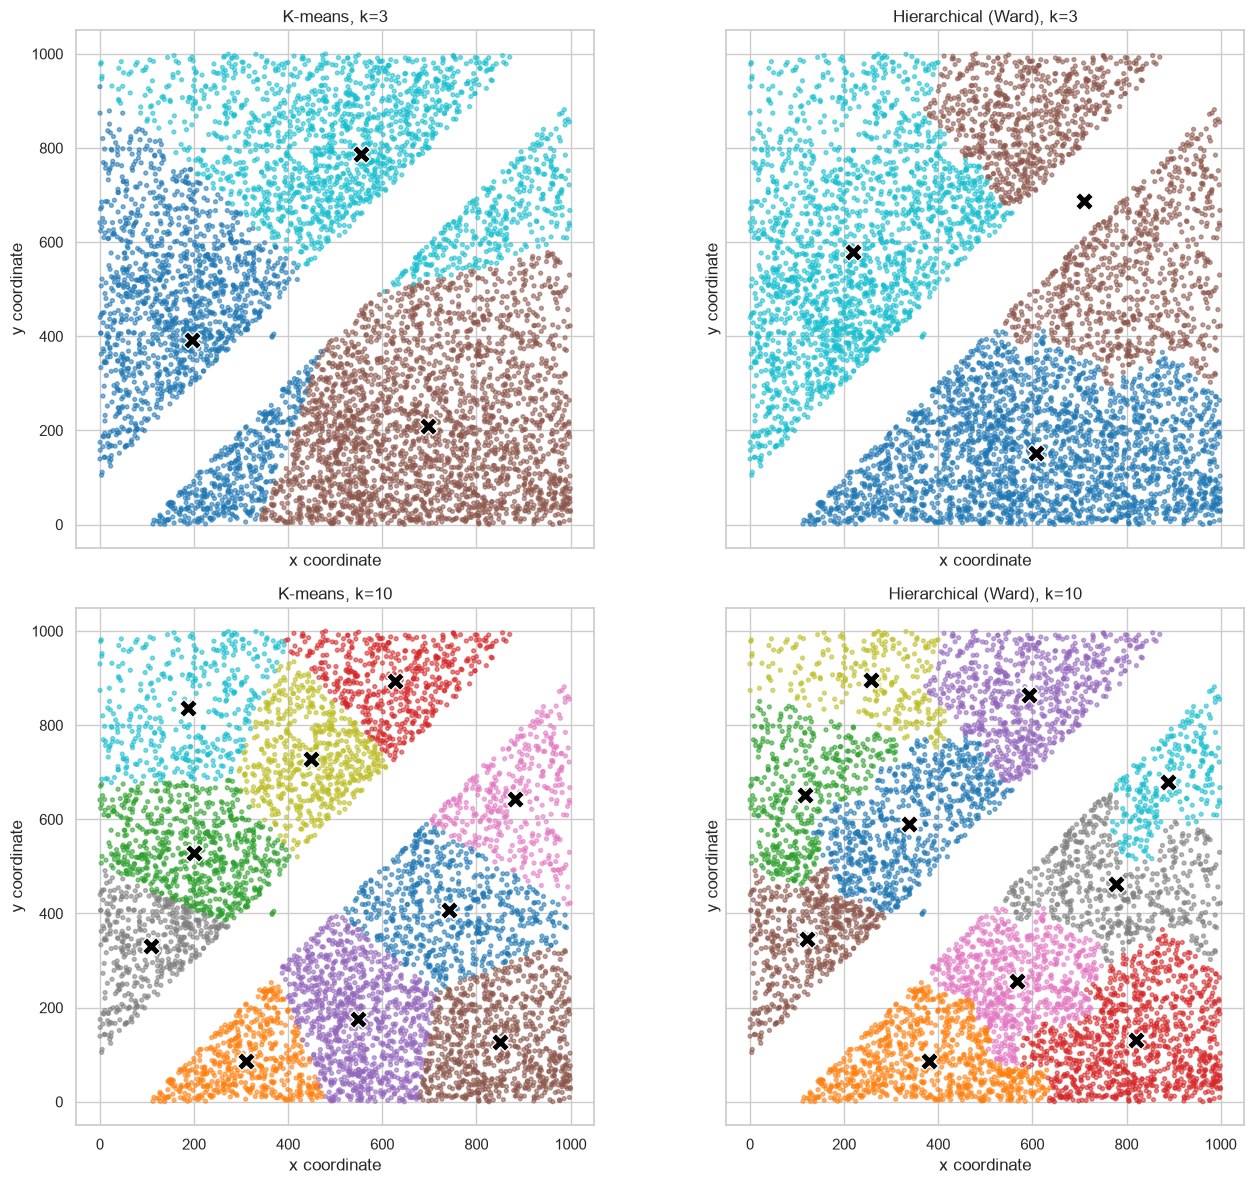

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)

for row, k in enumerate([3, 10]):
    km = kmeans_models[k]
    h = hierarchical_models[k]

    for ax, labels, title in [
        (axes[row, 0], km.labels_, f"K-means, k={k}"),
        (axes[row, 1], h.labels_, f"Hierarchical (Ward), k={k}"),
    ]:
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=8, alpha=0.55)
        centres = np.vstack([X[labels == label].mean(axis=0) for label in np.unique(labels)])
        ax.scatter(
            centres[:, 0], centres[:, 1], marker="X", s=170,
            c="black", edgecolors="white", linewidths=1
        )
        ax.set(title=title, xlabel="x coordinate", ylabel="y coordinate")
        ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

### 3.5 Depot recommendation

- If the company can initially fund only **three depots**, use the three k-means centres shown above as search areas. This is a compact starting network, but the average customer is still about 212 coordinate units from a depot.
- **Five depots** are a sensible compromise: the average distance falls to about 157 without creating a large network.
- If fast delivery coverage is worth the fixed cost, **ten depots** reduce the average distance to about 112 and the 90th percentile to about 171. The ten coordinates in the table are the proposed targets.

I would choose k-means for the operational proposal because it directly minimises squared distance to centroids, produces slightly shorter average distances here, and is easy to rerun as customers are added. Hierarchical clustering is useful as a sensitivity check: it shows that boundaries are not unique and can reveal nested group structure. Before leasing sites, both solutions need to be checked against roads, water, permitted airspace, land availability, depot capacity, and actual demand volume. A capacity-constrained or network-distance model would be a better second-stage model.

## 4. Part 2 — association rules

### 4.1 Data understanding and preparation

Each row is a transaction. `Prod1`–`Prod20` indicate whether at least one item from that group was purchased. The transaction ID is removed because it is not a product. `mlxtend` expects Boolean basket data, so the 0/1 columns are converted to `False`/`True`.

In [12]:
product_columns = [column for column in products.columns if column != "ID"]

product_quality = pd.Series({
    "missing values": int(products.isna().sum().sum()),
    "duplicate transaction IDs": int(products["ID"].duplicated().sum()),
    "non-binary product values": int(
        (~products[product_columns].isin([0, 1])).sum().sum()
    ),
    "transactions": len(products),
})
display(product_quality.to_frame("value"))

basket = products[product_columns].astype(bool)
basket_sizes = basket.sum(axis=1)

print(f"Average groups per transaction: {basket_sizes.mean():.2f}")
print(f"Empty transactions: {(basket_sizes == 0).sum():,} ({(basket_sizes == 0).mean():.1%})")

group_support = basket.mean().sort_values(ascending=False)
display(group_support.rename("support").to_frame().round(4))

,value
missing values,0
duplicate transaction IDs,0
non-binary product values,0
transactions,100000


Average groups per transaction: 2.24
Empty transactions: 19,520 (19.5%)


,support
Prod19,0.2063
Prod9,0.1985
Prod8,0.1618
Prod12,0.1597
Prod20,0.1480
Prod14,0.1456
Prod7,0.1350
Prod16,0.1310
Prod2,0.1310
Prod18,0.1217


Empty transactions do not contain any itemset, but they are kept because they are valid transactions and belong in the denominator of support. Removing them would make every rule look more common than it really is.

The support chart gives useful context: a high-confidence rule pointing to a very popular product can be less interesting than it first appears. Lift corrects for that baseline popularity.

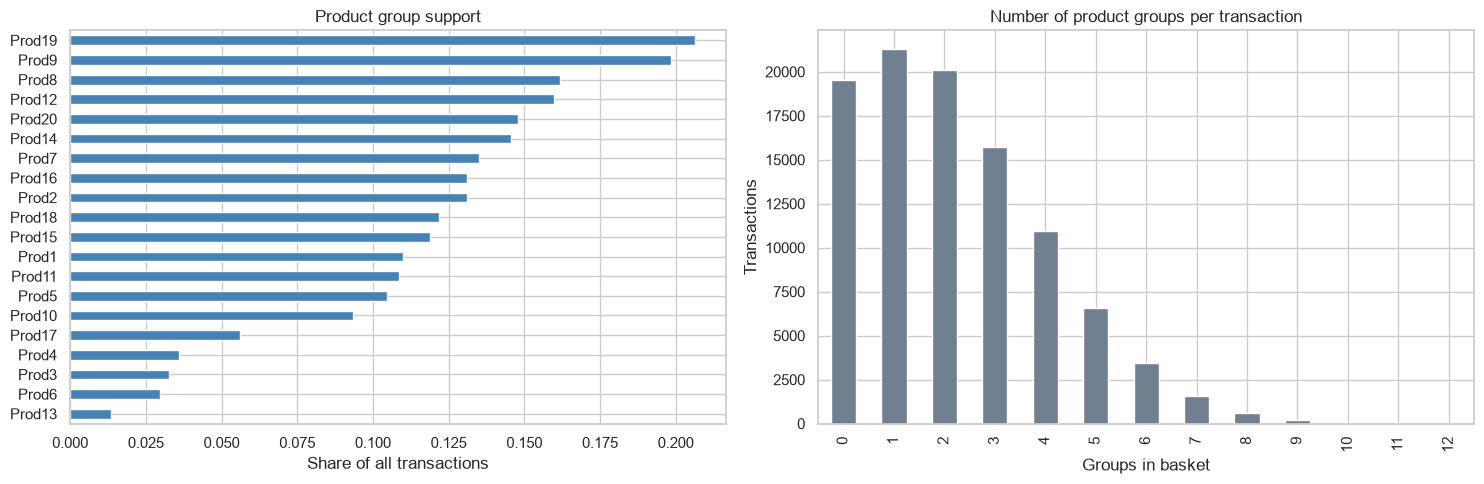

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

group_support.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set(title="Product group support", xlabel="Share of all transactions", ylabel="")

basket_sizes.value_counts().sort_index().plot.bar(ax=axes[1], color="slategray")
axes[1].set(title="Number of product groups per transaction", xlabel="Groups in basket", ylabel="Transactions")

plt.tight_layout()
plt.show()

### 4.2 Frequent itemsets and rules

Apriori first finds itemsets that occur in at least 1% of all transactions. With 100,000 rows, that means at least 1,000 baskets, so the results are not based on tiny counts. I limit itemsets to three product groups because the business question is about practical triggers, and very long conditions would be hard to use.

Rules then need at least 35% confidence. For the final shortlist I also require 2% support (2,000 transactions), lift of at least 1.3, no more than two trigger groups, and one recommended group. These thresholds keep the table useful rather than simply producing hundreds of rules.

In [14]:
MIN_ITEMSET_SUPPORT = 0.01
MIN_CONFIDENCE = 0.35
MIN_RULE_SUPPORT = 0.02
MIN_LIFT = 1.30

frequent_itemsets = apriori(
    basket,
    min_support=MIN_ITEMSET_SUPPORT,
    use_colnames=True,
    max_len=3,
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

actionable_rules = rules[
    (rules["support"] >= MIN_RULE_SUPPORT)
    & (rules["lift"] >= MIN_LIFT)
    & (rules["antecedents"].map(len) <= 2)
    & (rules["consequents"].map(len) == 1)
].copy()

def readable_itemset(itemset):
    return " + ".join(sorted(itemset))


actionable_rules["trigger"] = actionable_rules["antecedents"].map(readable_itemset)
actionable_rules["recommend"] = actionable_rules["consequents"].map(readable_itemset)
actionable_rules = actionable_rules.sort_values(
    ["lift", "support"], ascending=[False, False]
)

print(f"Frequent itemsets: {len(frequent_itemsets)}")
print(f"Rules before business filters: {len(rules)}")
print(f"Actionable shortlist: {len(actionable_rules)}")

Frequent itemsets: 168
Rules before business filters: 76
Actionable shortlist: 32


The first table uses single-product triggers, which are the easiest rules to deploy. The second table allows two products in the trigger. Support measures reach, confidence is the observed probability of the recommendation when the trigger is present, and lift compares that confidence with the recommendation's normal purchase rate.

In [15]:
report_columns = ["trigger", "recommend", "support", "confidence", "lift", "leverage", "conviction"]

single_trigger_rules = actionable_rules[
    actionable_rules["antecedents"].map(len) == 1
]

print("Single-product triggers")
display(single_trigger_rules[report_columns].head(10).round(4))

print("Strong rules including two-product triggers")
display(actionable_rules[report_columns].head(15).round(4))

Single-product triggers


,trigger,recommend,support,confidence,lift,leverage,conviction
2,Prod9,Prod15,0.1114,0.5614,4.7254,0.0879,2.0090
3,Prod15,Prod9,0.1114,0.9381,4.7254,0.0879,12.9544
4,Prod19,Prod20,0.1348,0.6534,4.4151,0.1042,2.4579
5,Prod20,Prod19,0.1348,0.9107,4.4151,0.1042,8.8848
0,Prod12,Prod5,0.0668,0.4184,4.0008,0.0501,1.5397
1,Prod5,Prod12,0.0668,0.6390,4.0008,0.0501,2.3275


Strong rules including two-product triggers


,trigger,recommend,support,confidence,lift,leverage,conviction
58,Prod20 + Prod9,Prod15,0.0212,0.5764,4.8522,0.0168,2.0805
56,Prod19 + Prod9,Prod15,0.0286,0.5727,4.8204,0.0227,2.0620
59,Prod15 + Prod20,Prod9,0.0212,0.9456,4.7628,0.0167,14.7221
48,Prod12 + Prod9,Prod15,0.0217,0.5651,4.7572,0.0172,2.0264
40,Prod8 + Prod9,Prod15,0.0220,0.5638,4.7461,0.0173,2.0203
49,Prod12 + Prod15,Prod9,0.0217,0.9415,4.7424,0.0171,13.7022
57,Prod15 + Prod19,Prod9,0.0286,0.9408,4.7389,0.0226,13.5404
2,Prod9,Prod15,0.1114,0.5614,4.7254,0.0879,2.0090
3,Prod15,Prod9,0.1114,0.9381,4.7254,0.0879,12.9544
41,Prod15 + Prod8,Prod9,0.0220,0.9332,4.7008,0.0173,12.0067


Three simple relationships stand out:

- **Prod15 → Prod9:** 93.8% confidence, 11.1% support, and lift about 4.73.
- **Prod20 → Prod19:** 91.1% confidence, 13.5% support, and lift about 4.42.
- **Prod5 → Prod12:** 63.9% confidence, 6.7% support, and lift about 4.00.

The reverse directions are also useful, but confidence changes because the groups have different baseline frequencies. For example, Prod9 → Prod15 has lower confidence than Prod15 → Prod9 even though both directions share the same support and lift.

Several two-product triggers have very high confidence, such as Prod15 + Prod20 → Prod9. They are good refinements when both trigger groups are already in the basket, but the single-trigger rules reach more customers and are simpler to deploy.

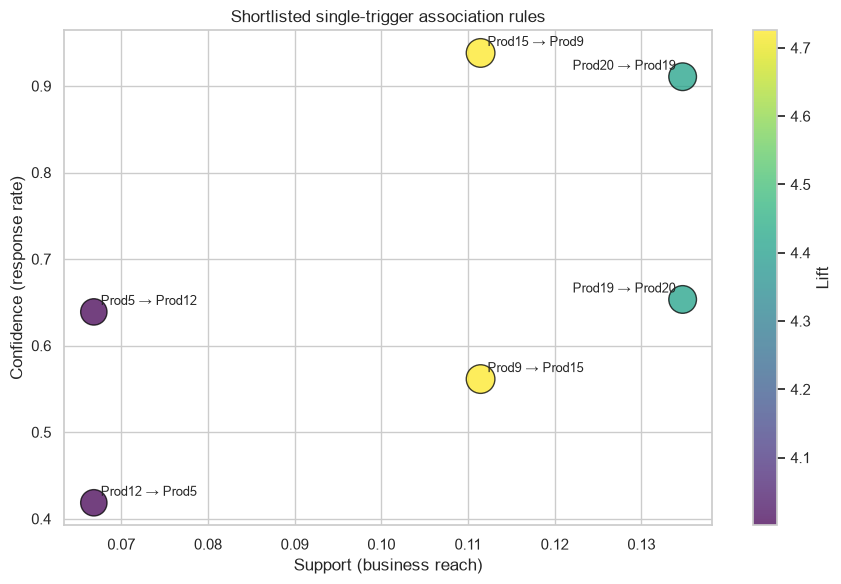

In [16]:
plot_rules = single_trigger_rules.head(10).copy()

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    plot_rules["support"],
    plot_rules["confidence"],
    s=plot_rules["lift"] * 90,
    c=plot_rules["lift"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="black",
)

for _, row in plot_rules.iterrows():
    place_left = row["support"] > 0.13
    ax.annotate(
        f"{row['trigger']} → {row['recommend']}",
        (row["support"], row["confidence"]),
        xytext=(-5 if place_left else 5, 5),
        textcoords="offset points",
        fontsize=9,
        ha="right" if place_left else "left",
    )

ax.set(
    title="Shortlisted single-trigger association rules",
    xlabel="Support (business reach)",
    ylabel="Confidence (response rate)",
)
fig.colorbar(points, ax=ax, label="Lift")
plt.tight_layout()
plt.show()

### 4.3 Revenue recommendation and deployment

The company should start with three basket prompts:

1. When **Prod15** is present and **Prod9** is absent, recommend Prod9.
2. When **Prod20** is present and **Prod19** is absent, recommend Prod19.
3. When **Prod5** is present and **Prod12** is absent, recommend Prod12.

These rules combine strong lift with meaningful support. They can be used as “frequently bought together” suggestions, small bundles, or targeted follow-up offers. The recommendation should only fire when the consequent is not already in the basket.

Association does not prove that the trigger causes the extra purchase. I would A/B test each prompt against a no-prompt control and measure incremental conversion, revenue, margin, and return rate. Discounts should not be automatic: first test a plain recommendation, because discounting a pair customers already buy together may reduce margin. Rules should also be refreshed on a schedule and checked by customer segment, season, stock level, and product-group meaning.

## 5. Final conclusion

The depot data supports a staged decision rather than one universally “correct” k. Three k-means depots are a low-cost starting point, five are a balanced option, and ten nearly halve the mean straight-line customer distance compared with three. K-means is the preferred operational model, while hierarchical clustering is a useful robustness check.

For revenue growth, the strongest simple cross-sell tests are Prod15 → Prod9, Prod20 → Prod19, and Prod5 → Prod12. Their lifts are around four or higher, so the relationships are much stronger than the product groups' baseline purchase rates. The next CRISP-DM cycle should validate depot feasibility with real travel constraints and validate the product prompts with controlled experiments.